In [1]:
!pip install opencv-python

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Load Image and Print Details

In [4]:
img = cv2.imread('/content/sample.jpg')

# OpenCV loads as BGR
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Shape:", img_rgb.shape)
print("Dtype:", img_rgb.dtype)

print("Red channel min/max:",
      img_rgb[:,:,0].min(),
      img_rgb[:,:,0].max())

print("Green channel min/max:",
      img_rgb[:,:,1].min(),
      img_rgb[:,:,1].max())

print("Blue channel min/max:",
      img_rgb[:,:,2].min(),
      img_rgb[:,:,2].max())

Shape: (725, 800, 3)
Dtype: uint8
Red channel min/max: 0 255
Green channel min/max: 0 227
Blue channel min/max: 0 190


Convert from RGB to Grayscale to HSV

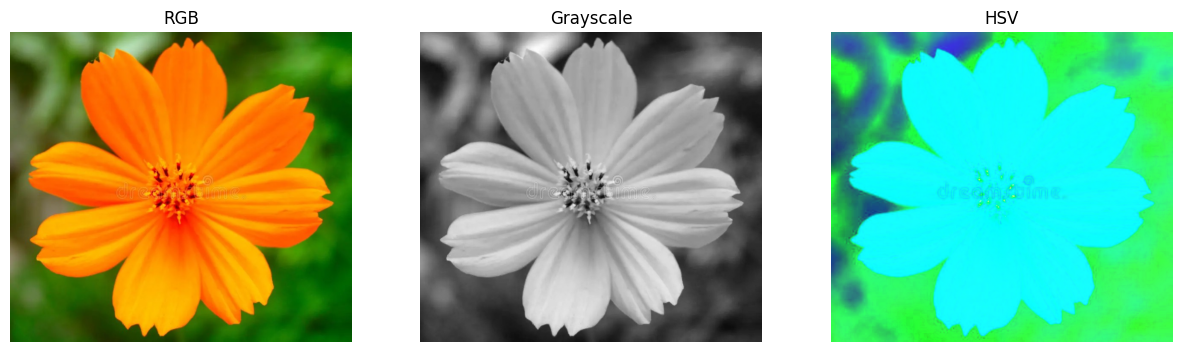

In [5]:
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(hsv)
plt.title("HSV")
plt.axis("off")

plt.show()

2D Convolution from Scratch: Sobel X

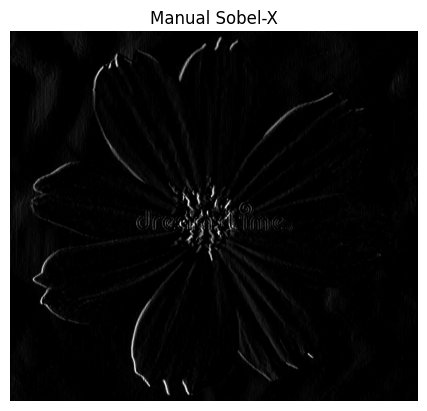

In [6]:
sobel_x = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

h, w = gray.shape

output = np.zeros((h-2, w-2))

for i in range(h-2):
    for j in range(w-2):

        region = gray[i:i+3, j:j+3]

        value = np.sum(region * sobel_x)

        output[i,j] = value

output = np.clip(output, 0, 255)
output = output.astype(np.uint8)

plt.imshow(output, cmap='gray')
plt.title("Manual Sobel-X")
plt.axis("off")
plt.show()

Gaussian Blur

In [7]:
blur = cv2.GaussianBlur(img_rgb, (5,5), 0)

Sharpening

In [8]:
sharpen_kernel = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
])

sharp = cv2.filter2D(img_rgb, -1, sharpen_kernel)

Canny-> what is it?

In [9]:
canny = cv2.Canny(gray, 100, 200)

Displaying the outputs of Gaussian Blur,Sharpening and Canny

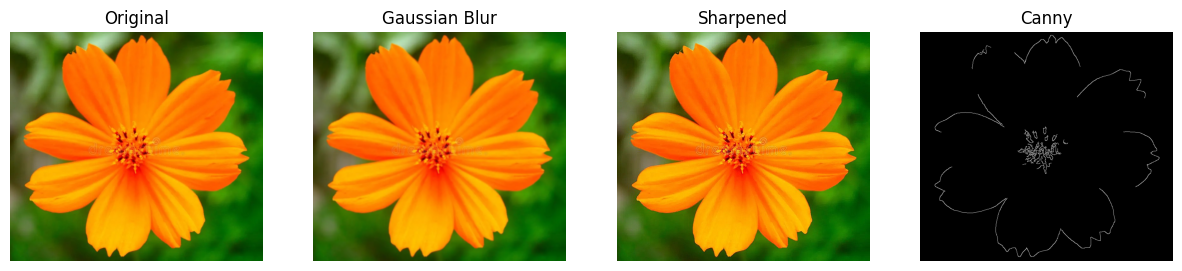

In [12]:
plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(blur)
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(sharp)
plt.title("Sharpened")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(canny, cmap='gray')
plt.title("Canny")
plt.axis("off")

plt.show()

Histogram Equalisation

In [13]:
equalized = cv2.equalizeHist(gray)

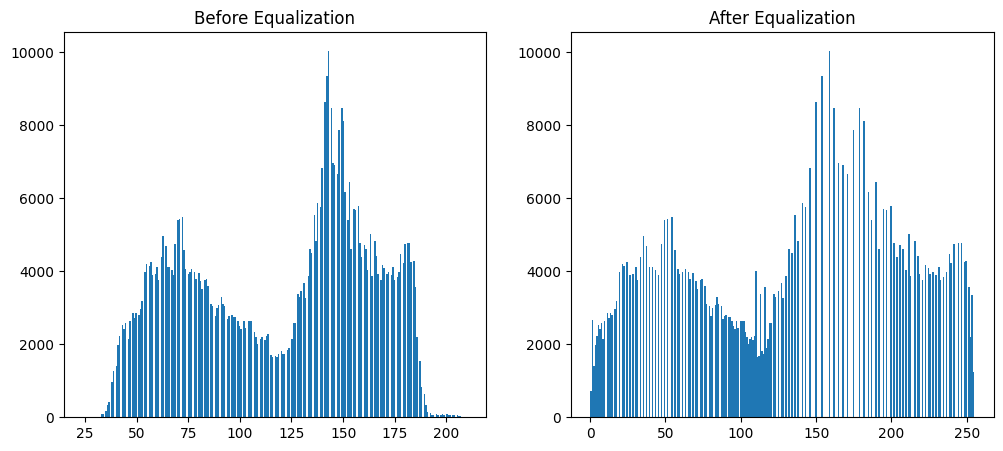

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(gray.ravel(), bins=256)
plt.title("Before Equalization")

plt.subplot(1,2,2)
plt.hist(equalized.ravel(), bins=256)
plt.title("After Equalization")

plt.show()

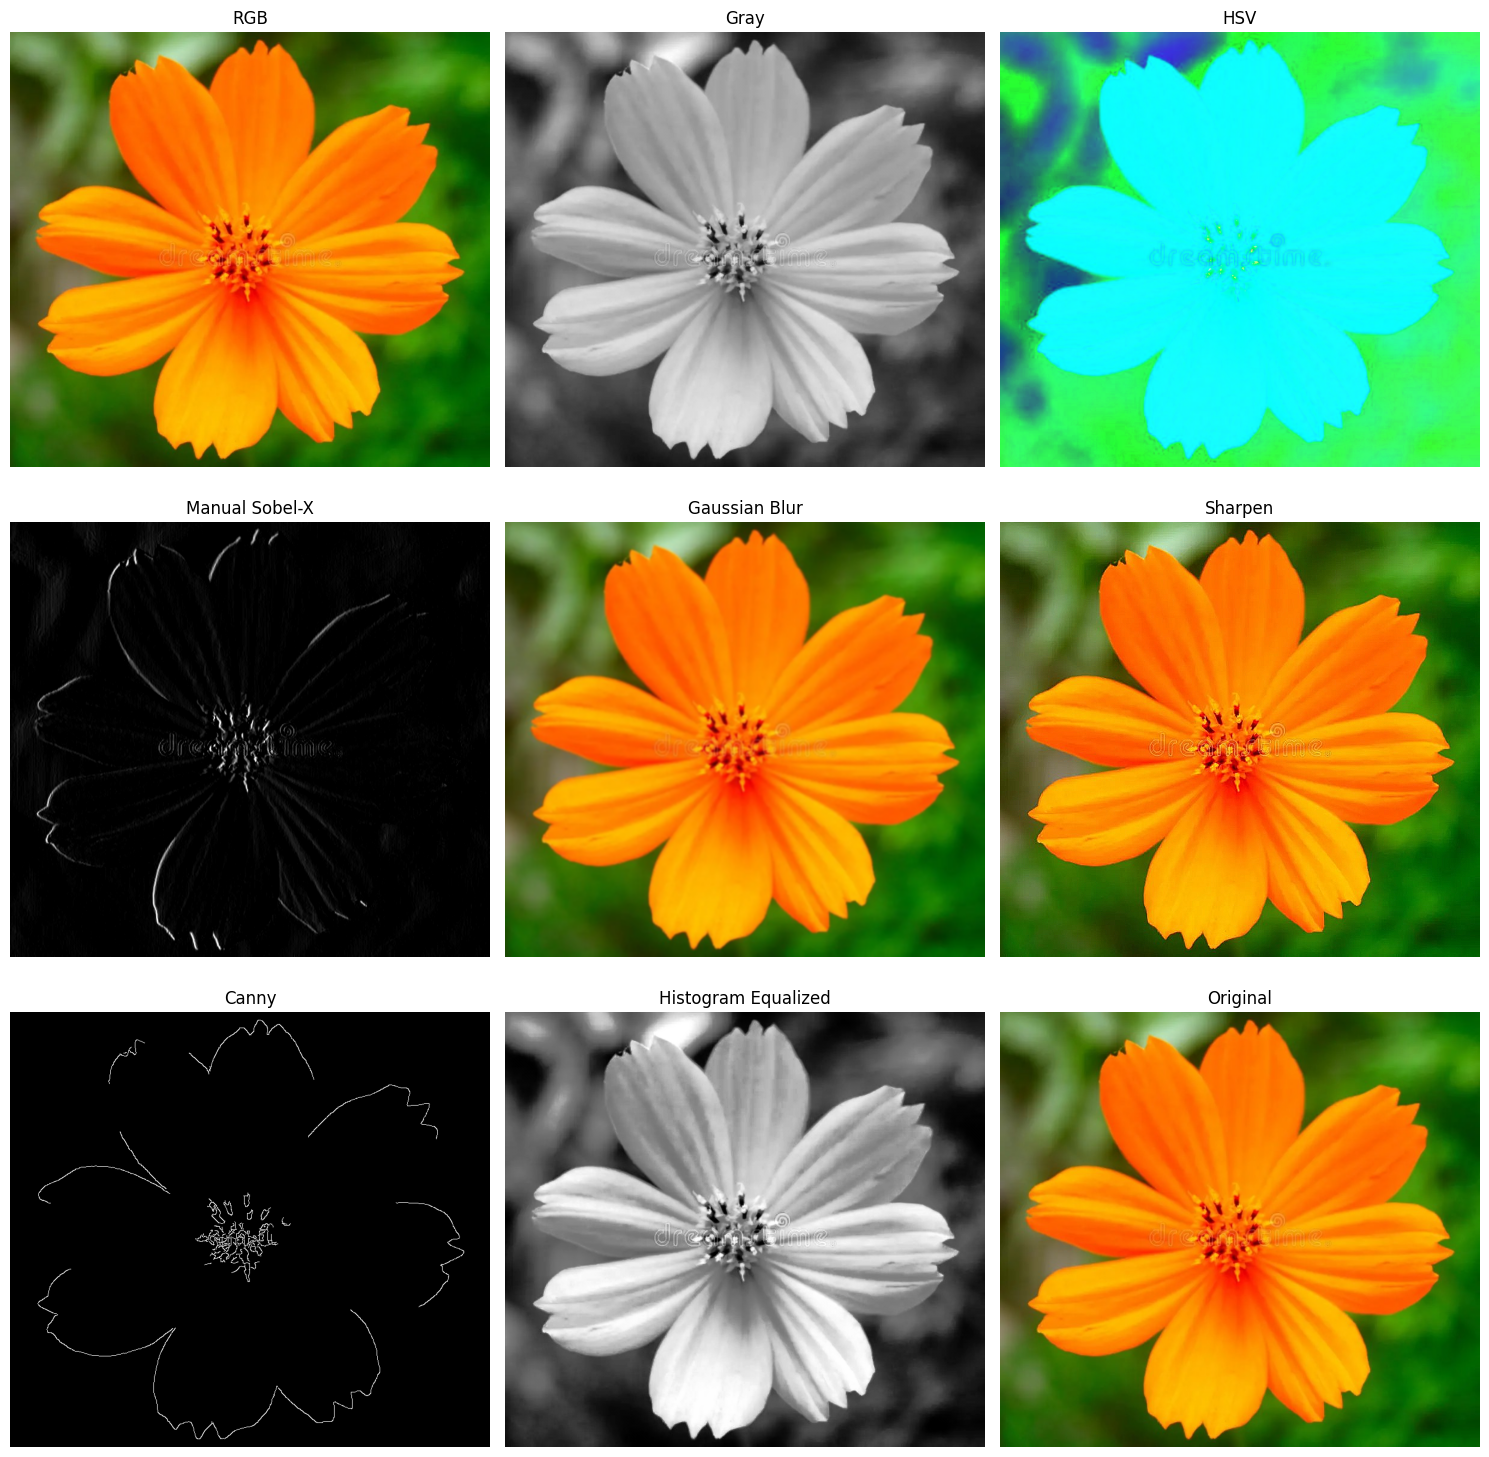

In [15]:
fig, axes = plt.subplots(3,3, figsize=(15,15))

images = [
    img_rgb,
    gray,
    hsv,
    output,
    blur,
    sharp,
    canny,
    equalized,
    img_rgb
]

titles = [
    "RGB",
    "Gray",
    "HSV",
    "Manual Sobel-X",
    "Gaussian Blur",
    "Sharpen",
    "Canny",
    "Histogram Equalized",
    "Original"
]

for ax, im, title in zip(axes.ravel(), images, titles):

    if len(im.shape) == 2:
        ax.imshow(im, cmap='gray')
    else:
        ax.imshow(im)

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()

plt.savefig("results_grid.png")

plt.show()